Detected classes: ['no', 'yes']
Number of images in 'no': 92
Number of images in 'yes': 155


C:\Users\Admin\AppData\Local\Temp\ipykernel_10028\1771006693.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(files_dict.keys()), y=[len(files_dict[c]) for c in files_dict], palette="Greens_d")


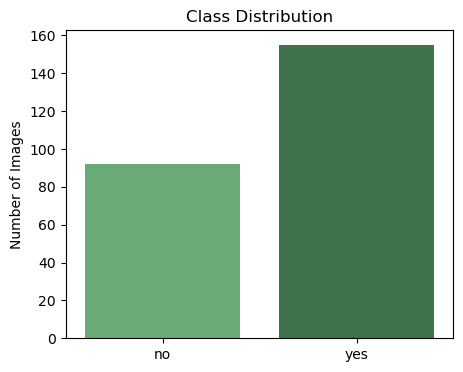

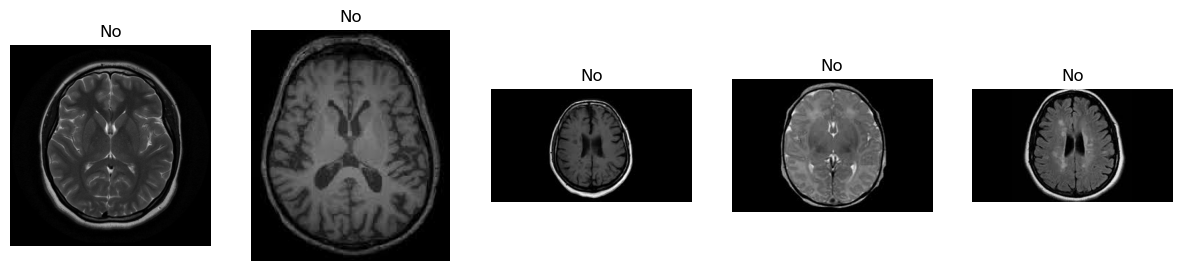

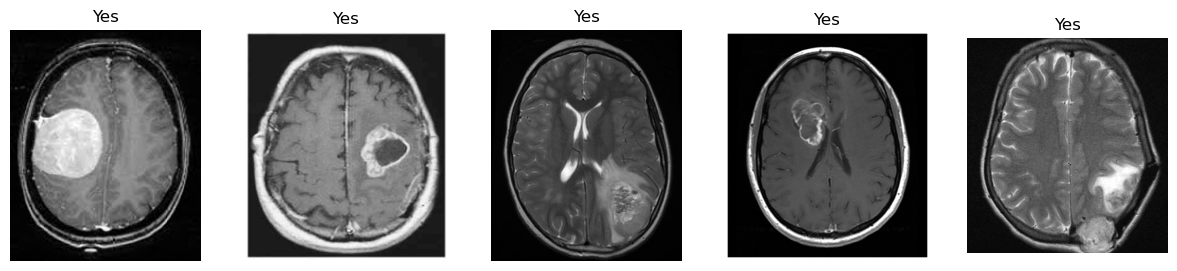

Sample image shape: (201, 173, 3)
Image data type: uint8


In [2]:
import os
import matplotlib.pyplot as plt
import cv2
import seaborn as sns


dataset_path = r"F:\ml projects\brain tumor detector\data\brain_tumor_dataset"

class_dirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print(f"Detected classes: {class_dirs}")

files_dict = {}
for class_name in class_dirs:
    class_path = os.path.join(dataset_path, class_name)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png'))]
    files_dict[class_name] = files
    print(f"Number of images in '{class_name}': {len(files)}")

# Class distribution plot
plt.figure(figsize=(5,4))
sns.barplot(x=list(files_dict.keys()), y=[len(files_dict[c]) for c in files_dict], palette="Greens_d")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

# Function to show sample images from each class
def show_samples(class_dir, class_name, n=5):
    files = os.listdir(class_dir)
    plt.figure(figsize=(15, 3))
    for i in range(min(n, len(files))):
        img_path = os.path.join(class_dir, files[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(class_name)
    plt.show()

# Show samples from each detected class
for class_name in class_dirs:
    show_samples(os.path.join(dataset_path, class_name), class_name.capitalize())

# Check one image shape & datatype
sample_img = cv2.imread(os.path.join(dataset_path, class_dirs[0], files_dict[class_dirs[0]][0]))
print(f"Sample image shape: {sample_img.shape}")
print(f"Image data type: {sample_img.dtype}")

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Target image size for the model
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = r"F:\ml projects\brain tumor detector\data\brain_tumor_dataset"

# Train-validation split using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,              
    validation_split=0.2,        
    rotation_range=15,           
    width_shift_range=0.1,       
    height_shift_range=0.1,      
    zoom_range=0.1,              
    horizontal_flip=True,        
    fill_mode='nearest'          
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

print(f"Class indices: {train_generator.class_indices}")

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Class indices: {'no': 0, 'yes': 1}


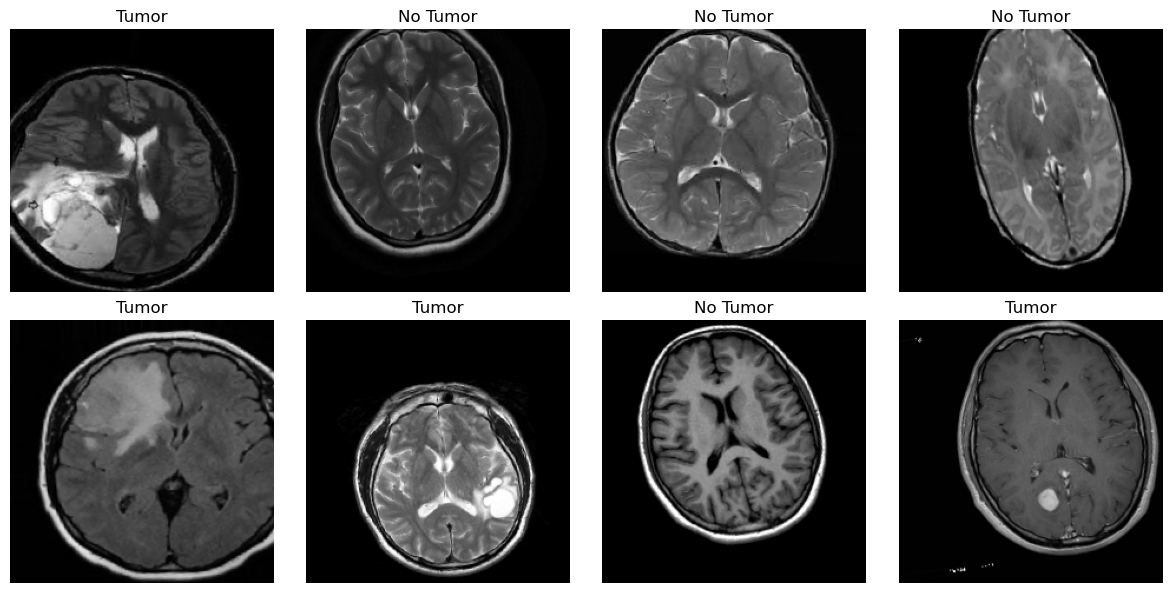

In [6]:
# Get one batch of augmented images & labels
images, labels = next(train_generator)

# Create a 2x4 grid for 8 sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    label_text = "Tumor" if labels[i] == 1 else "No Tumor"
    ax.set_title(label_text, color='black', fontsize=12)
    ax.axis('off')

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

In [7]:
# Step 3: Modeling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# CNN Architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=20,  # You can adjust this
    validation_data=val_generator
)

F:\madhu\envs\brain_tumor\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 67s 6s/step - accuracy: 0.5468 - loss: 0.9452 - val_accuracy: 0.6800 - val_loss: 0.6085
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6995 - loss: 0.6095 - val_accuracy: 0.7000 - val_loss: 0.5503
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6601 - loss: 0.6005 - val_accuracy: 0.7200 - val_loss: 0.5344
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7685 - loss: 0.5458 - val_accuracy: 0.7600 - val_loss: 0.6300
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7537 - loss: 0.5484 - val_accuracy: 0.7200 - val_loss: 0.5189
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7488 - loss: 0.5253 - val_accuracy: 0.7600 - val_loss: 0.5234
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7488 - loss: 0.5333 - val_accuracy: 0.7600 - val_loss: 0.4874
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.8079 - loss: 0.4900 - val_accuracy: 0.7400 - val_loss: 0.6683
Epoch 9/

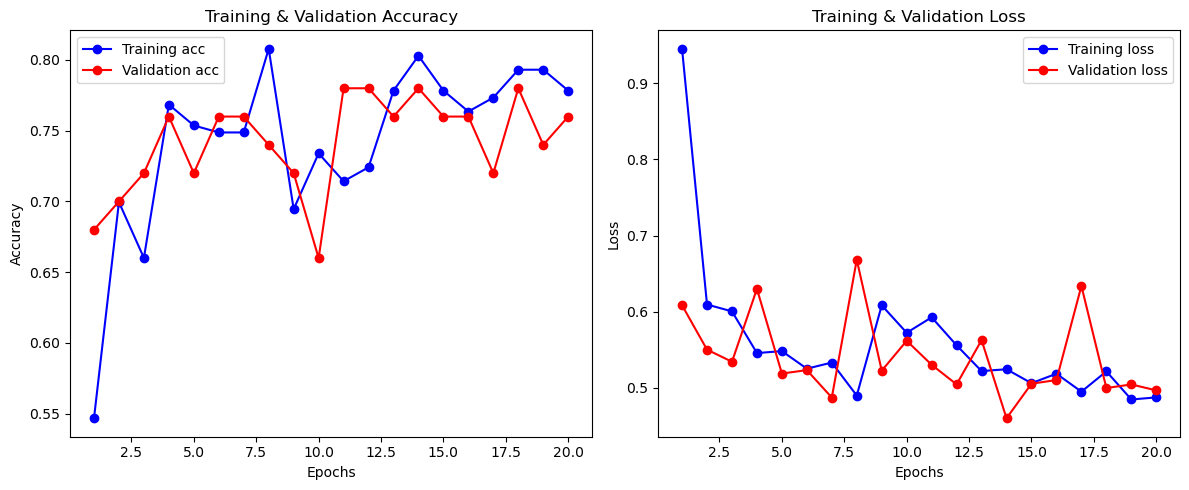

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 572ms/step


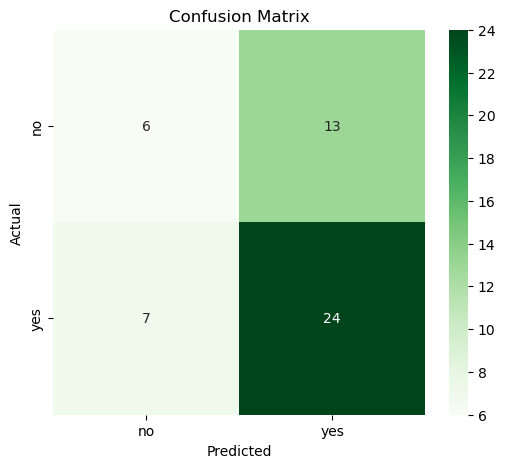

Classification Report:
              precision    recall  f1-score   support

          no       0.46      0.32      0.38        19
         yes       0.65      0.77      0.71        31

    accuracy                           0.60        50
   macro avg       0.56      0.54      0.54        50
weighted avg       0.58      0.60      0.58        50



In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Plot Accuracy & Loss Curves
def plot_training_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'bo-', label='Training acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training & Validation Accuracy')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training & Validation Loss')

    plt.tight_layout()
    plt.show()

# Call plot function
plot_training_curves(history)

# 2. Confusion Matrix
# Predict classes for validation data
val_generator.reset()
preds = model.predict(val_generator)
y_pred = (preds > 0.5).astype(int).reshape(-1)

# True labels
y_true = val_generator.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

In [9]:
#Transfer Learning with EfficientNetB0
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load the EfficientNetB0 model with pretrained ImageNet weights
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,  # Remove original classifier
    input_shape=(224, 224, 3)
)

# 2️⃣ Freeze the base model's layers (initial training)
base_model.trainable = False

# 3️⃣ Add our MRI classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)  # Helps reduce overfitting
output = Dense(1, activation='sigmoid')(x)  # Binary classification

model = Model(inputs=base_model.input, outputs=output)

# 4️⃣ Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5️⃣ Train the classifier head on your MRI data
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=10  # Initial stage is quick
)

# Optional: Fine-tuning stage — unfreeze top layers
base_model.trainable = True
for layer in base_model.layers[:-20]:  # Keep early layers frozen
    layer.trainable = False

# Recompile with a smaller learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fine-tune — short training to avoid overfitting
history_ft = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=5
)

# Save the fine-tuned model for Step 4
model.save("efficientnetb0_mri_brain_tumor.h5")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 0.5172 - loss: 0.6915 - val_accuracy: 0.6200 - val_loss: 0.6657
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6108 - loss: 0.6933 - val_accuracy: 0.6200 - val_loss: 0.6673
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6010 - loss: 0.6832 - val_accuracy: 0.6200 - val_loss: 0.6667
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5911 - loss: 0.6840 - val_accuracy: 0.6200 - val_loss: 0.6693
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6010 - loss: 0.6709 - val_accuracy: 0.6200 - val_loss: 0.6641
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6059 - loss: 0.6776 - val_accuracy: 0.6200 - val_loss: 0.6642
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6108 - loss: 0.6731 - val_accuracy: 0.6200 - val_loss: 0.6639
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6108 - loss: 0.6657